<a href="https://colab.research.google.com/github/MituShil/biosign-dashboard-/blob/main/notebooks/biosign_day0_first_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello!I am building the Biosign Dasgboard")

Hello!I am building the Biosign Dasgboard


In [ ]:
print("This project scores exoplanets for biosignature likelihood")


This project scores exoplanets for biosignature likelihood


In [1]:
print("Built by: Mitu Shil")


Built by: Mitu Shil


🛰️ Connecting to NASA Exoplanet Archive...
✅ Successfully loaded 4687 real exoplanets from NASA data streams!


/tmp/ipykernel_2215/1936753707.py:75: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


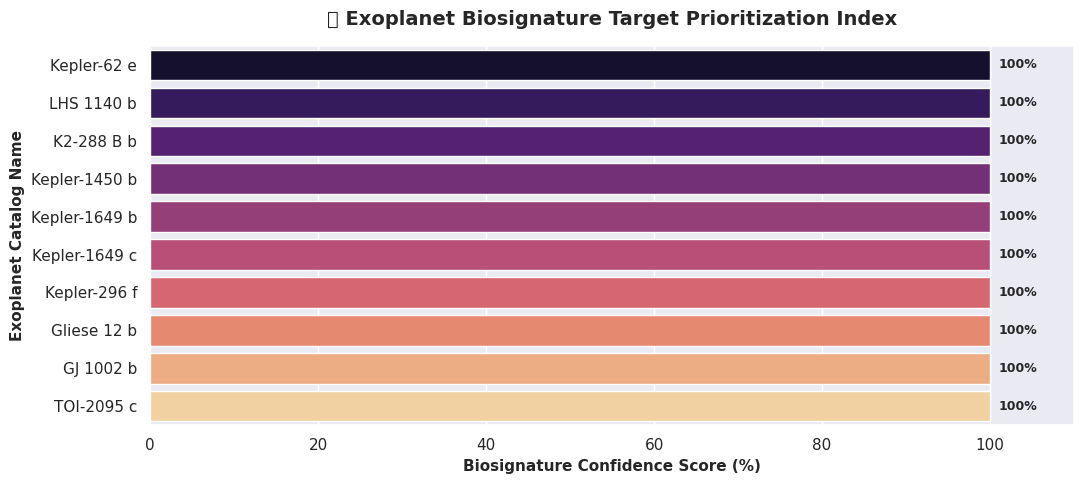

In [4]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to the live NASA Exoplanet Archive using Table Access Protocol (TAP) in CSV format
print("🛰️ Connecting to NASA Exoplanet Archive...")
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# Use explicit CSV parameters to guarantee an error-free data structural return
query = "?query=select+pl_name,hostname,pl_eqt,st_teff,pl_rade+from+pscomppars+where+pl_eqt+is+not+null&format=csv"

response = requests.get(base_url + query)

# Safely catch the raw text data stream into a memory string and convert it into a Pandas spreadsheet
df = pd.read_csv(io.StringIO(response.text))
print(f"✅ Successfully loaded {len(df)} real exoplanets from NASA data streams!")

# 2. Define Astrochemistry Bio-Scoring Constraints
def calculate_biosignature_score(row):
    score = 0
    temp = row['pl_eqt']     # Thermodynamic equilibrium temp in Kelvin
    radius = row['pl_rade']  # Core physical size boundary metric

    # Rule A: Liquid Water & Atmosphere Stability Zone (200K to 320K)
    if 200 <= temp <= 320:
        score += 40
    elif 320 < temp <= 400:
        score += 15

    # Rule B: Terrestrial/Rocky vs Gas Giant Filtration (Radius <= 2.0 Earth Radii)
    if radius is not None and radius <= 2.0:
        score += 40
    elif radius is not None and radius <= 4.0:
        score += 20

    # Rule C: Host Star Spectroscopic Baseline Compatibility (K & M-Dwarfs)
    if 3000 <= row['st_teff'] <= 5000:
        score += 20

    return score

# Process dataset entries
df['Biosignature_Confidence_Score'] = df.apply(calculate_biosignature_score, axis=1)

# Isolate the top candidates to display
ranked_df = df.sort_values(by='Biosignature_Confidence_Score', ascending=False).head(10)

# 3. Build a Professional, High-Density Visual Chart
plt.figure(figsize=(11, 5))
sns.set_theme(style="darkgrid")

ax = sns.barplot(
    x='Biosignature_Confidence_Score',
    y='pl_name',
    data=ranked_df,
    palette='magma',
    hue='pl_name',
    legend=False
)

# Visual anchors for presentation charts
plt.title("🌌 Exoplanet Biosignature Target Prioritization Index", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Biosignature Confidence Score (%)", fontsize=11, fontweight='bold')
plt.ylabel("Exoplanet Catalog Name", fontsize=11, fontweight='bold')
plt.xlim(0, 110)

# Display calculated scores on each individual data bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2, f'{int(width)}%',
            ha="left", va="center", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



